# Просмотр чанков

Чанки из `03_chunks` + PNG страницы из `01_extracted_pages`.

In [17]:
import json
from pathlib import Path
from IPython.display import display, Markdown, Image as IPyImage

if Path('/workspace/data').exists():
    BASE = Path('/workspace')
else:
    BASE = Path.cwd().parent.parent

OCR_DIR    = BASE / 'data' / '01_extracted_pages'
NORM_DIR   = BASE / 'data' / '02_normalized_text'
CHUNKS_DIR = BASE / 'data' / '03_chunks'

chunk_docs = sorted([d for d in CHUNKS_DIR.iterdir() if d.is_dir()])
print('Документы:')
for d in chunk_docs:
    f = d / 'chunks.json'
    if f.exists():
        n = len(json.loads(f.read_text(encoding='utf-8')))
        print(f'  {d.name}: {n} чанков')

Документы:


In [18]:
# --- Выберите документ ---
DOC = chunk_docs[0]

chunks = json.loads((CHUNKS_DIR / DOC.name / 'chunks.json').read_text(encoding='utf-8'))

# PNG страниц
page_pngs = {}
ocr_doc_dir = OCR_DIR / DOC.name
if ocr_doc_dir.exists():
    for f in sorted(ocr_doc_dir.glob('page_*.png')):
        parts = f.stem.split('_')
        if len(parts) == 2:
            page_pngs[int(parts[1])] = f

# Нормализованный текст для сопоставления text-чанков со страницами
page_texts = {}  # page_num -> text
norm_doc_dir = NORM_DIR / DOC.name
if norm_doc_dir.exists():
    for pf in sorted(norm_doc_dir.glob('page_*.json')):
        d = json.loads(pf.read_text(encoding='utf-8'))
        page_texts[d['page']] = d.get('text', '')

def find_page(chunk_text: str) -> int | None:
    """Для text-чанков ищем страницу по первым 60 символам текста."""
    raw = chunk_text
    if raw.startswith('['):  # убираем breadcrumb [раздел]\n
        nl = raw.find('\n')
        if nl != -1:
            raw = raw[nl + 1:]
    probe = raw.strip()[:60]
    if not probe:
        return None
    for pg_num, pg_text in page_texts.items():
        if probe in pg_text:
            return pg_num
    return None

# Проставляем page для text-чанков
for c in chunks:
    if c['page'] is None and c['type'] == 'text':
        c['page'] = find_page(c['text'])

print(f'Документ : {DOC.name}')
print(f'Чанков   : {len(chunks)}')
print(f'  text   : {sum(1 for c in chunks if c["type"]=="text")}')
print(f'  table  : {sum(1 for c in chunks if c["type"]=="table")}')
print(f'  image  : {sum(1 for c in chunks if c["type"]=="image")}')
print(f'PNG      : {len(page_pngs)}')

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\kozlovaalek\\Projects\\LLM\\data\\03_chunks\\CEN1_ТИ_3-48200234-05.1-12-2020_Очистка_электролита_от_примесей\\chunks.json'

## Просмотр чанков

---
### Чанк 90 · Текст · стр. 74
**Раздел:** 6 Примечание > 6.1 Теоретические основы процесса

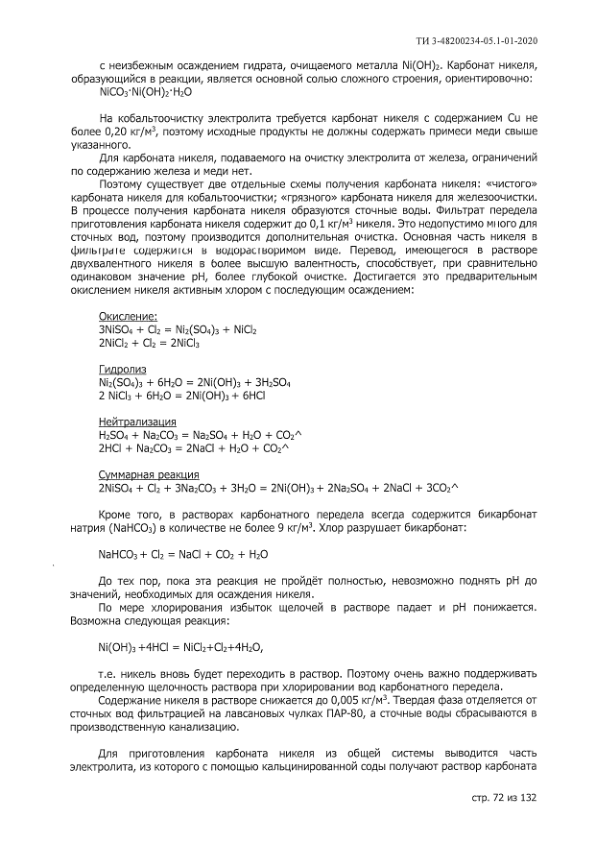

[6 Примечание > 6.1 Теоретические основы процесса]
ржать примеси меди свыше
указанного.

Для карбоната никеля, подаваемого на очистку электролита от железа, ограничений
по содержанию железа и меди нет.

Поэтому существует две отдельные схемы получения карбоната никеля: «чистого»
    о  о
В процессе получения карбоната никеля образуются сточные воды. Фильтрат передела
приготовления карбоната никеля содержит до 0,1 кг/м3 никеля. Это недопустимо много для
   
фильтрате содержится в водорастворимом виде. Перевод, имеющегося в растворе
двухвалентного никеля в более высшую валентность, способствует, при сравнительно
одинаковом значение рН, более глубокой очистке. Достигается это предварительным
 

Окисление: 3NISO, + C2 = Ni2(SO4)3 + NIClz
2NiCl2 + Cl2 = 2NiCl3

Гидролиз
Niz(SOs)3 + 6H:O = 2Ni(OH)3 + 3H2SO
2 NiCl; + 6H;2O = 2Ni(OH), + 6HC1

Нейтрализация
H2SO + NazCO, = NazSO + HzO + CO2^
2HCl + NazCO, = 2NaCl + HzO + CO2^

Суммарная реакция
2NiSO, + C, + 3Na;CO, + 3H;0 = 2Ni(OH)3 + 2Na,SO, + 2NaCl + 3C02^


натрия (NаНСОз) в количестве не более 9 кг/м3. Хлор разрушает бикарбонат:

NaHCOз + Cl, = NaCl + COz + HzO

До тех пор, пока эта реакция не пройдёт полностью, невозможно поднять рН до
значений, необходимых для осаждения никеля.

По мере хлорирования избыток щелочей в растворе падает и рН понижается.
Возможна следующая реакция:

Ni(OH)3 +4HCl = NiCl2+C2+4Hz0,

  
определенную щелочность раствора при хлорировании вод карбонатного передела

---
### Чанк 91 · Текст · стр. 74
**Раздел:** 6 Примечание > 6.1 Теоретические основы процесса

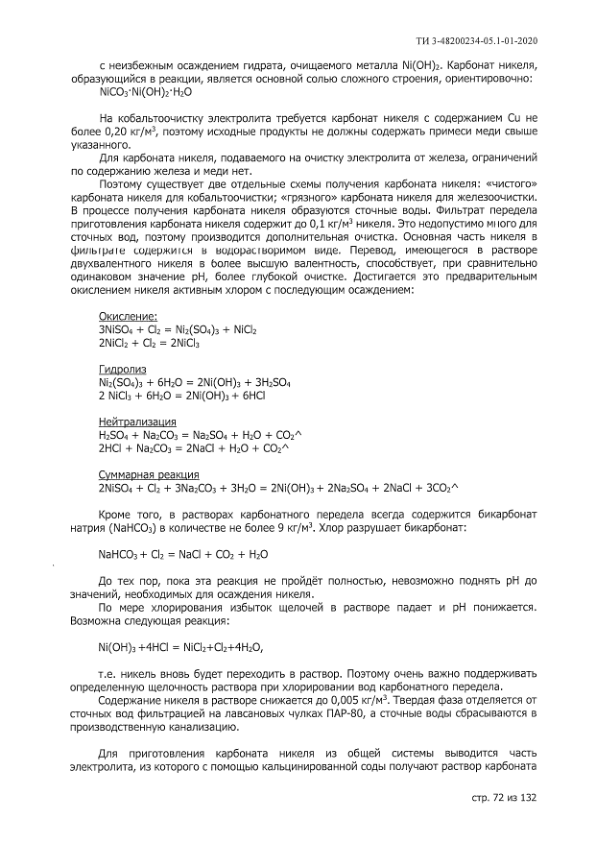

[6 Примечание > 6.1 Теоретические основы процесса]
онижается.
Возможна следующая реакция:

Ni(OH)3 +4HCl = NiCl2+C2+4Hz0,

  
определенную щелочность раствора при хлорировании вод карбонатного передела

Содержание никеля в растворе снижается до 0,оо5 кг/м3. Твердая фаза отделяется от
сточных вод фильтрацией на лавсановых чулках ПАр-80, а сточные воды сбрасываются в
производственную канализацию.

никеля. Образовавшийся №іСо; сгущают, отфильтровывают на дисковых вакуум-фильтрах.
Растворы, содержащие в основном №а;SО, присоединяют к сточным водам тем самым
предотвращается накопление в электролите №а;SО4. Содержание в электролите №а-SО,
определяется между количеством его, вводимым в электролит с карбонатом никеля
     
водами. Полученный карбонат, состоящий из смеси №іСо; и основных солей, применяется
так и малых примесей. для нейтрализации при всех операциях гидролитической очистки как основных (Fе, Со),

       
ионов, хлор-ионов и ионов натрия.

Вывод хлор-ионов со сточными водами нежелателен, так как ухудшаются условия
электролиза никеля, поэтому предпочтительнее использовать растворы с незначительным
содержанием хлор-иона.

Для получения карбоната никеля необходим раствор кальцинированной соды, его
приготовление, хранение и транспортировка осуществляется в механизированном складе.

---
### Чанк 92 · Текст · стр. 75
**Раздел:** 6 Примечание > 6.2 Производство карбоната никеля

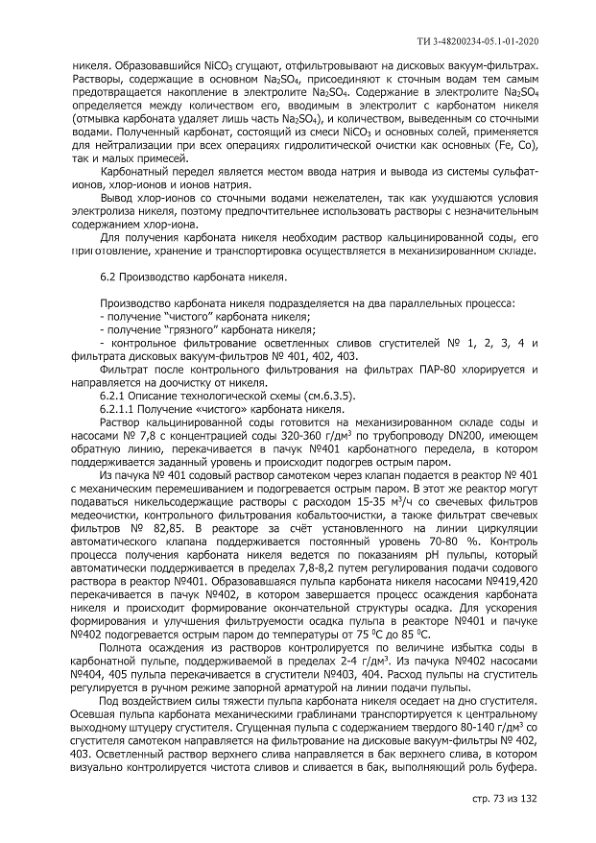

[6 Примечание > 6.2 Производство карбоната никеля]
6.2 Производство карбоната никеля.

   

 -получение"чистого"карбоната никеля;

 -

- контрольное фильтрование осветленных сливов сгустителей № 1, 2, 3, 4 и
фильтрата дисковых вакуум-фильтров № 401, 402, 403.

Фильтрат после контрольного фильтрования на фильтрах ПАр-80 хлорируется и
направляется на доочистку от никеля.

6.2.1 Описание технологической схемы (см.6.3.5).

6.2.1.1 Получение «чистого» карбоната никеля.

Раствор кальцинированной соды готовится на механизированном складе соды и
насосами № 7,8 с концентрацией соды 320-360 г/дм3по трубопроводу Д№2о0, имеющем
обратную линию, перекачивается в пачук №е4о1 карбонатного передела, в котором
поддерживается заданный уровень и происходит подогрев острым паром.

Йз пачука № 401 содовый раствор самотеком через клапан подается в реактор № 401
 
 -

автоматического клапана поддерживается постоянный уровень 70-80 %. Контроль фильтров № 82,85. В реакторе за счёт установленного на линии циркуляции

 -
раствора в реактор №401. Образовавшаяся пульпа карбоната никеля насосами №419,420
перекачивается в пачук №е4о2, в котором завершается процесс осаждения карбоната
оофои
формирования и улучшения фильтруемости осадка пульпа в реакторе №о401 и пачуке
№е402 подогревается острым паром до температуры от 75 °С до 85 °С.

   л   и 
карбонатной пульпе, поддерживаемой в пределах 2-4 г/дм3. Из пачука №9402 насосами
№404, 405 пульпа перекачивается в сгустители №9403, 404. Расход пульпы на сгуститель

---
### Чанк 93 · Текст · стр. 75
**Раздел:** 6 Примечание > 6.2 Производство карбоната никеля

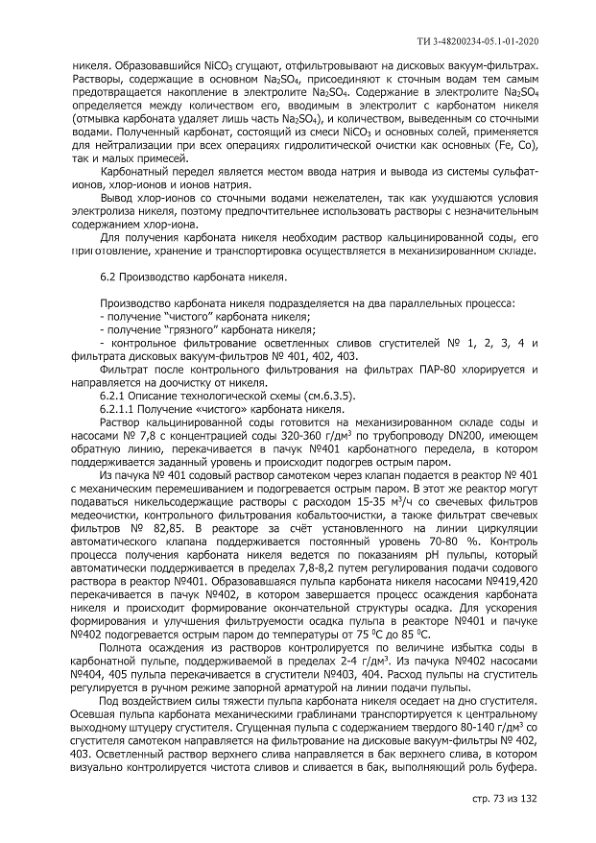

[6 Примечание > 6.2 Производство карбоната никеля]
живаемой в пределах 2-4 г/дм3. Из пачука №9402 насосами
№404, 405 пульпа перекачивается в сгустители №9403, 404. Расход пульпы на сгуститель
         

Под воздействием силы тяжести пульпа карбоната никеля оседает на дно сгустителя.
Осевшая пульпа карбоната механическими граблинами транспортируется к центральному
-  
сгустителя самотеком направляется на фильтрование на дисковые вакуум-фильтры №е 402,
403. Осветленный раствор верхнего слива направляется в бак верхнего слива, в котором
  я

Из буферного бака насосами № 412, 413 осветлённый слив сгустителей откачивается на
контрольное фильтрование на рукавные фильтры ПАР-80 № 401,402.

 
репульпаторы с механическим перемешиванием, где распульповывается никелевым
раствором. Полученная пульпа насосами № 414, 415 откачивается в пачук №404, в котором
производится подогрев и выравнивание плотности пульпы путем непрерывного
перемешивания ее сжатым воздухом.

Откорректированная пульпа карбоната никеля с содержанием твердого в пределах
150-250 г/дм3 и меди до 0,2 г/дм3из пачука №о404 насосными №о424,425 подается на
передел очистки электролита от кобальта. В случае необходимости проведения каких-либо
работ на линии подачи «грязного» карбоната на переделе железоочистки, для
предотвращения нарушения технологического процесса очистки от железа, существует
- 

никеля.

---
### Чанк 94 · Текст · стр. 76
**Раздел:** 6 Примечание > 6.2 Производство карбоната никеля

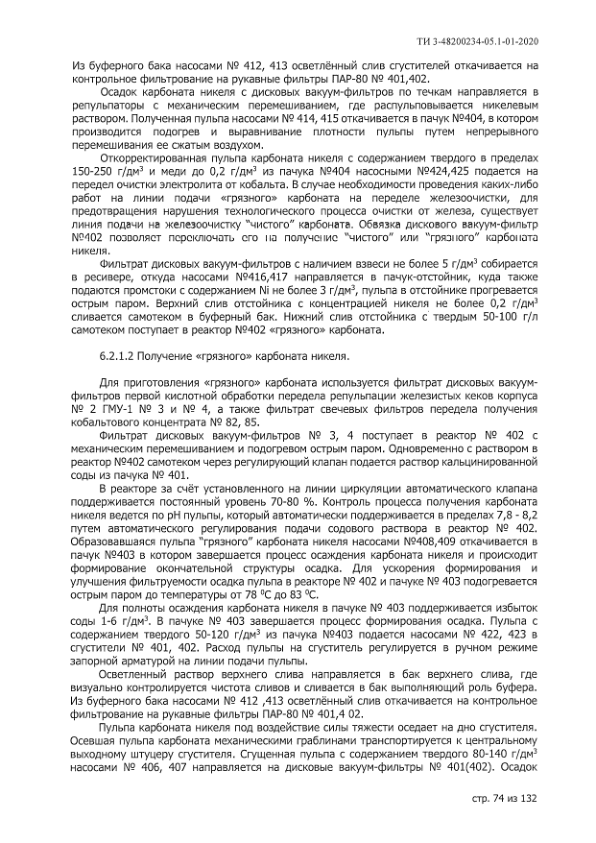

[6 Примечание > 6.2 Производство карбоната никеля]
и «грязного» карбоната на переделе железоочистки, для
предотвращения нарушения технологического процесса очистки от железа, существует
- 

никеля.

  

подаются промстоки с содержанием №і не более 3 г/дм², пульпа в отстойнике прогревается
острым паром. Верхний слив отстойника с концентрацией никеля не более ó,2 г/дм"
сливается самотеком в буферный бак. Нижний слив отстойника с твердым 50-100 г/л
самотеком поступает в реактор №е4о2 «грязного» карбоната.

6.2.1.2 Получение «грязного» карбоната никеля.

 л 
фильтров первой кислотной обработки передела репульпации железистых кеков корпуса
№ 2 гМУ-1 № 3 и № 4, а также фильтрат свечевых фильтров передела получения
кобальтового концентрата № 82, 85.

Фильтрат дисковых вакуум-фильтров № 3, 4 поступает в реактор №о 402 с

соды из пачука № 401. реактор №о402 самотеком через регулирующий клапан подается раствор кальцинированной

---
### Чанк 95 · Текст · стр. 76
**Раздел:** 6 Примечание > 6.2 Производство карбоната никеля

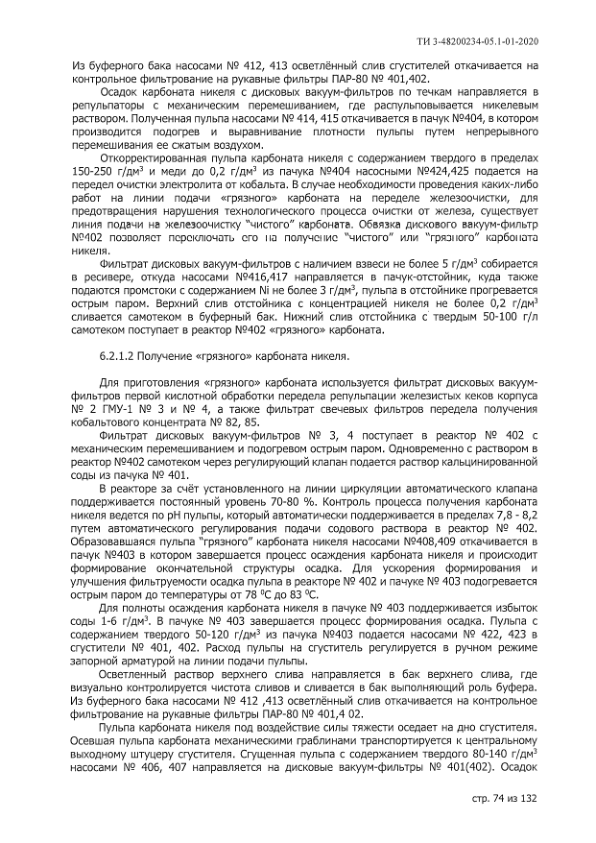

[6 Примечание > 6.2 Производство карбоната никеля]
ильтров № 3, 4 поступает в реактор №о 402 с

соды из пачука № 401. реактор №о402 самотеком через регулирующий клапан подается раствор кальцинированной

В реакторе за счёт установленного на линии циркуляции автоматического клапана
поддерживается постоянный уровень 70-80 %. Контроль процесса получения карбоната
никеля ведется по рН пульпы, который автоматически поддерживается в пределах 7,8 - 8,2
      
Образовавшаяся пульпа "трязного" карбоната никеля насосами №о4о8,409 откачивается в
пачук №о4оз в котором завершается процесс осаждения карбоната никеля и происходит
формирование окончательной структуры осадка. Для ускорения формирования и
улучшения фильтруемости осадка пульпа в реакторе № 402 и пачуке № 403 подогревается
острым паром до температуры от 78 °С до 83 °С.

Для полноты осаждения карбоната никеля в пачуке №о 403 поддерживается избыток
соды 1-6 г/дм". В пачуке № 403 завершается процесс формирования осадка. Пульпа с
содержанием твердого 50-120 г/дм3 из пачука №9403 подается насосами № 422, 423 в
сгустители № 401, 402. Расход пульпы на сгуститель регулируется в ручном режиме
 o  o ooe

Осветленный раствор верхнего слива направляется в бак верхнего слива, где
визуально контролируется чистота сливов и сливается в бак выполняющий роль буфера.
Из буферного бака насосами № 412 ,413 осветлённый слив откачивается на контрольное
фильтрование на рукавные фильтры ПАР-80 № 401,4 02.

Пульпа карбоната никеля под воздействие силы тяжести оседает на дно сгустителя.

In [ ]:
# ── Настройки ──────────────────────────────────────────────
CHUNK_FROM  = 90      # с какого chunk_id
CHUNK_TO    = 95     # по какой chunk_id включительно
IMG_WIDTH   = 600
FILTER_TYPE = None   # None = все; 'text' / 'table' / 'image'
# ───────────────────────────────────────────────────────────

TYPE_ICON = {'text': 'Текст', 'table': 'Таблица', 'image': 'Изображение'}

for c in chunks:
    cid = c['chunk_id']
    if not (CHUNK_FROM <= cid <= CHUNK_TO):
        continue
    if FILTER_TYPE and c['type'] != FILTER_TYPE:
        continue

    pg   = c.get('page')
    bc   = c.get('header_breadcrumb') or '—'
    kind = TYPE_ICON.get(c['type'], c['type'])

    display(Markdown(f'---\n### Чанк {cid} · {kind} · стр. {pg}\n**Раздел:** {bc}'))

    png = page_pngs.get(pg)
    if png:
        display(IPyImage(filename=str(png), width=IMG_WIDTH))

    display(Markdown(c['text']))